
Dataset : golang-web-server-performance
Target  : ['cpu_limit', 'cpu_usage', 'n', 'c', 'ram_limit_mb', 'ram_usage_mb', 'lat50_ms', 'lat66_ms', 'lat75_ms', 'lat80_ms', 'lat90_ms', 'lat95_ms', 'lat98_ms', 'lat99_ms', 'lat100_ms']
test_input  : (3864, 24)
WaveStitch+ : (3864, 24)
ground truth: (3864, 24)

Time range: 2022-03-17 06:52:39  →  2022-03-17 11:10:11


Feature                  Observed   True Missing     Masked
cpu_limit                     737           3034         93
cpu_usage                     737           3034         93
n                             737           3034         93
c                             737           3034         93
ram_limit_mb                  737           3034         93
ram_usage_mb                  737           3034         93
lat50_ms                      737           3034         93
lat66_ms                      737           3034         93
lat75_ms                      737           3034         93
lat80_ms                      737    

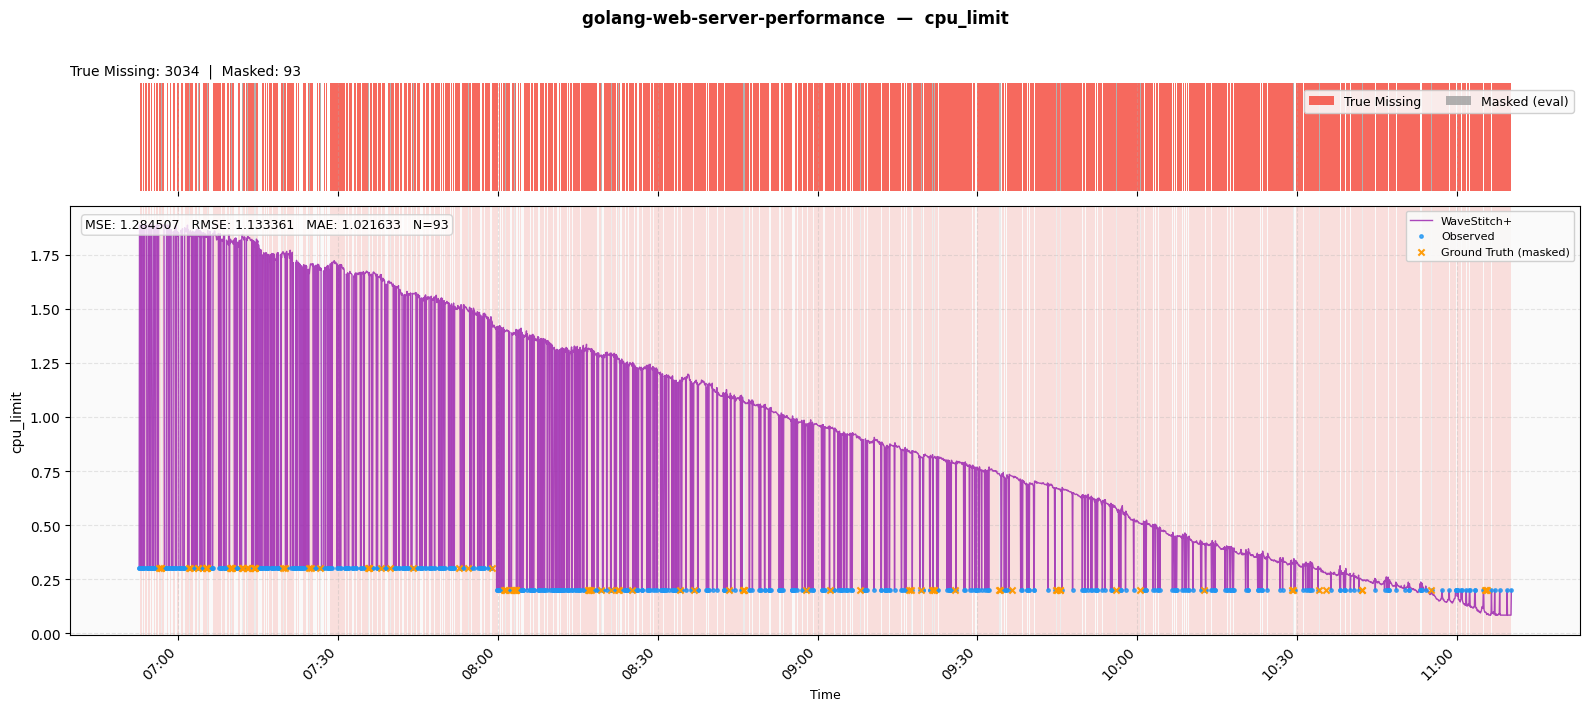

  [SAVED] EUR/curated/golang-web-server-performance/manual__2026-02-25T08:23:29.080265+00:00/comparison_plots/cpu_limit_wavestitchplus.png


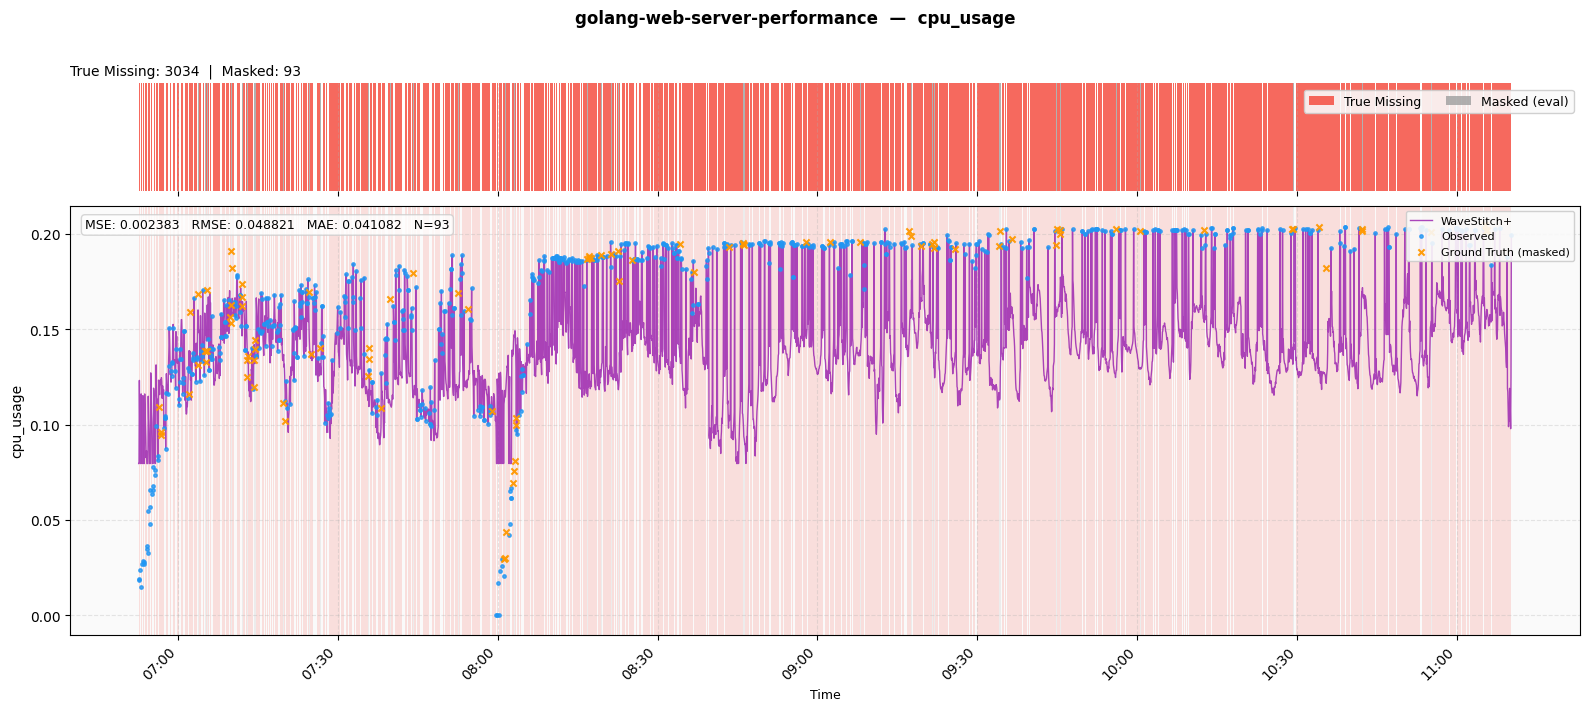

  [SAVED] EUR/curated/golang-web-server-performance/manual__2026-02-25T08:23:29.080265+00:00/comparison_plots/cpu_usage_wavestitchplus.png


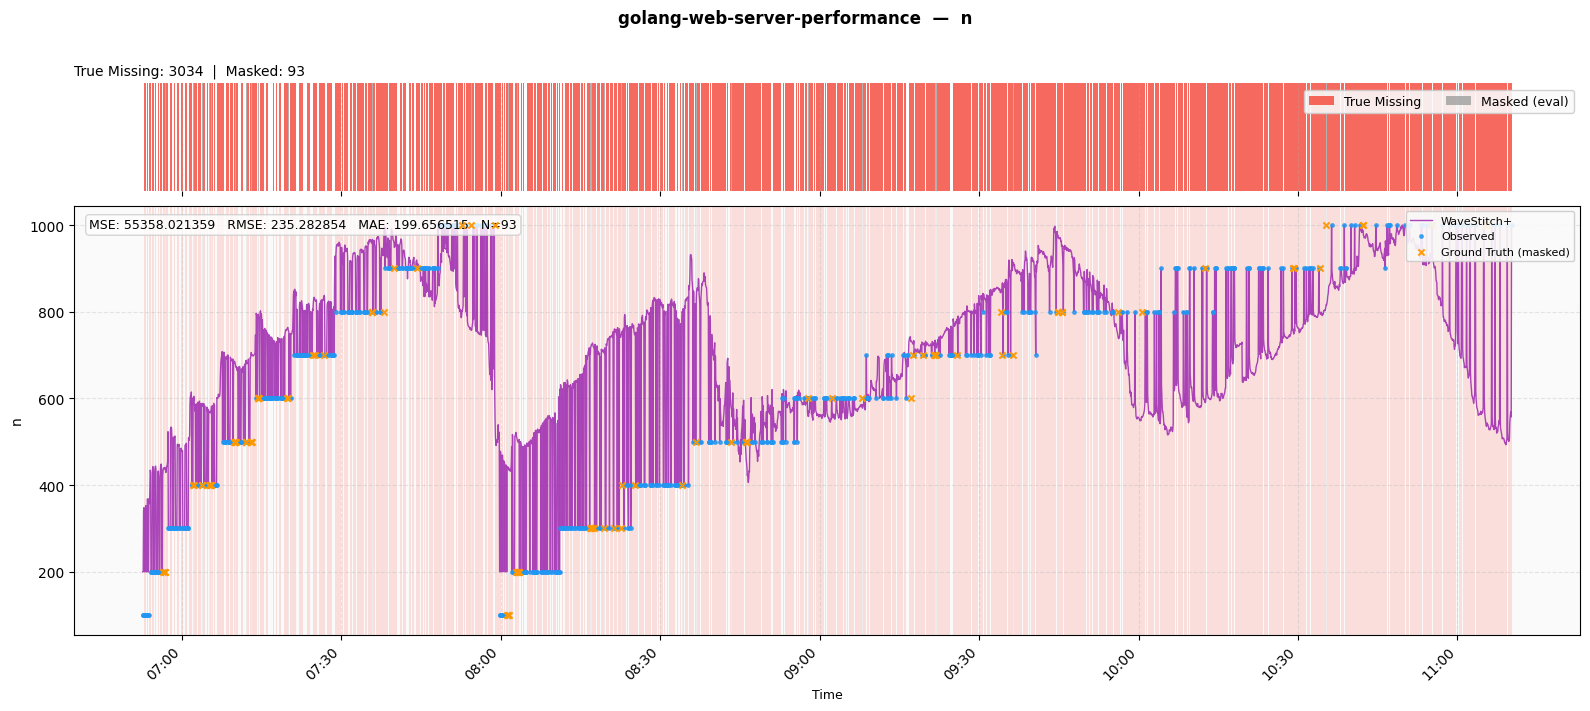

  [SAVED] EUR/curated/golang-web-server-performance/manual__2026-02-25T08:23:29.080265+00:00/comparison_plots/n_wavestitchplus.png


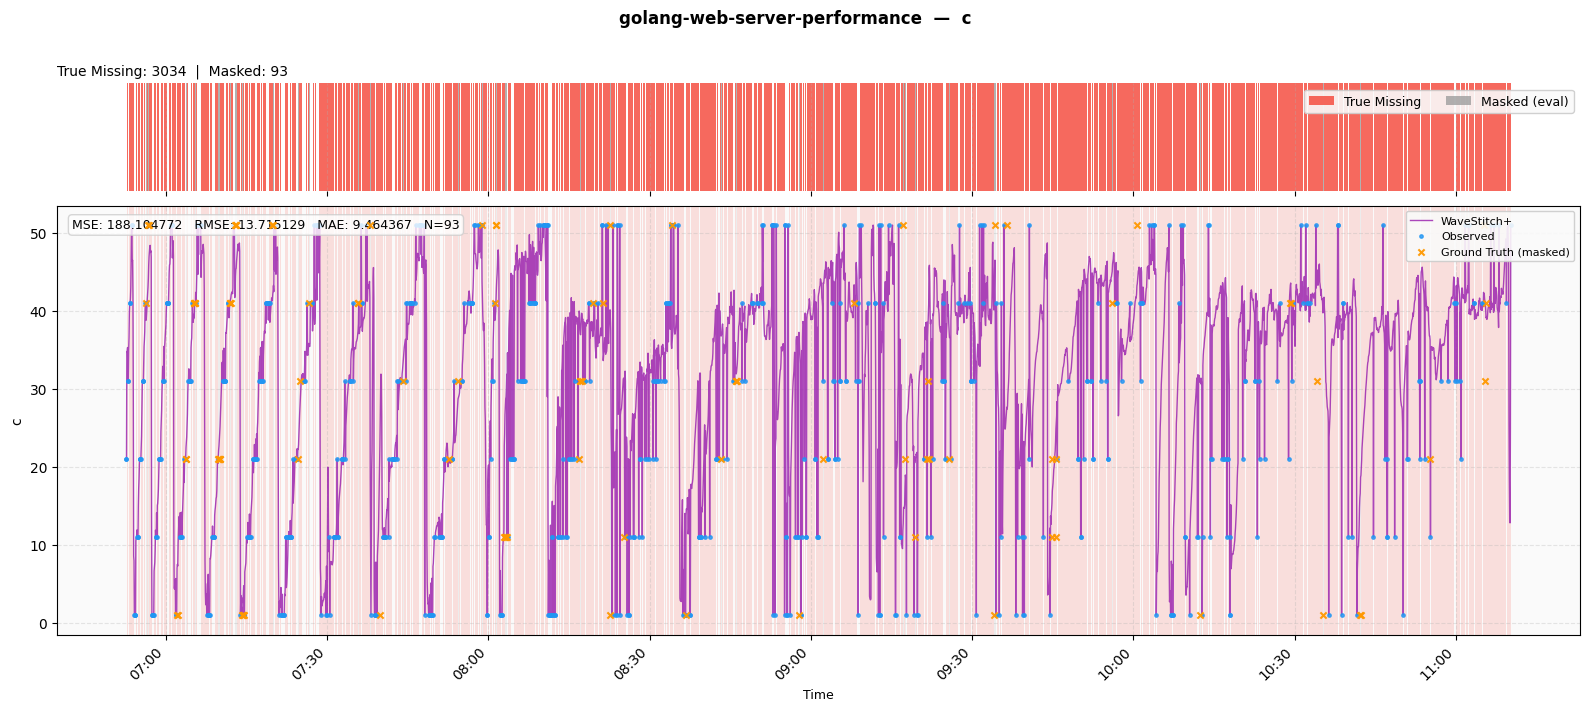

  [SAVED] EUR/curated/golang-web-server-performance/manual__2026-02-25T08:23:29.080265+00:00/comparison_plots/c_wavestitchplus.png


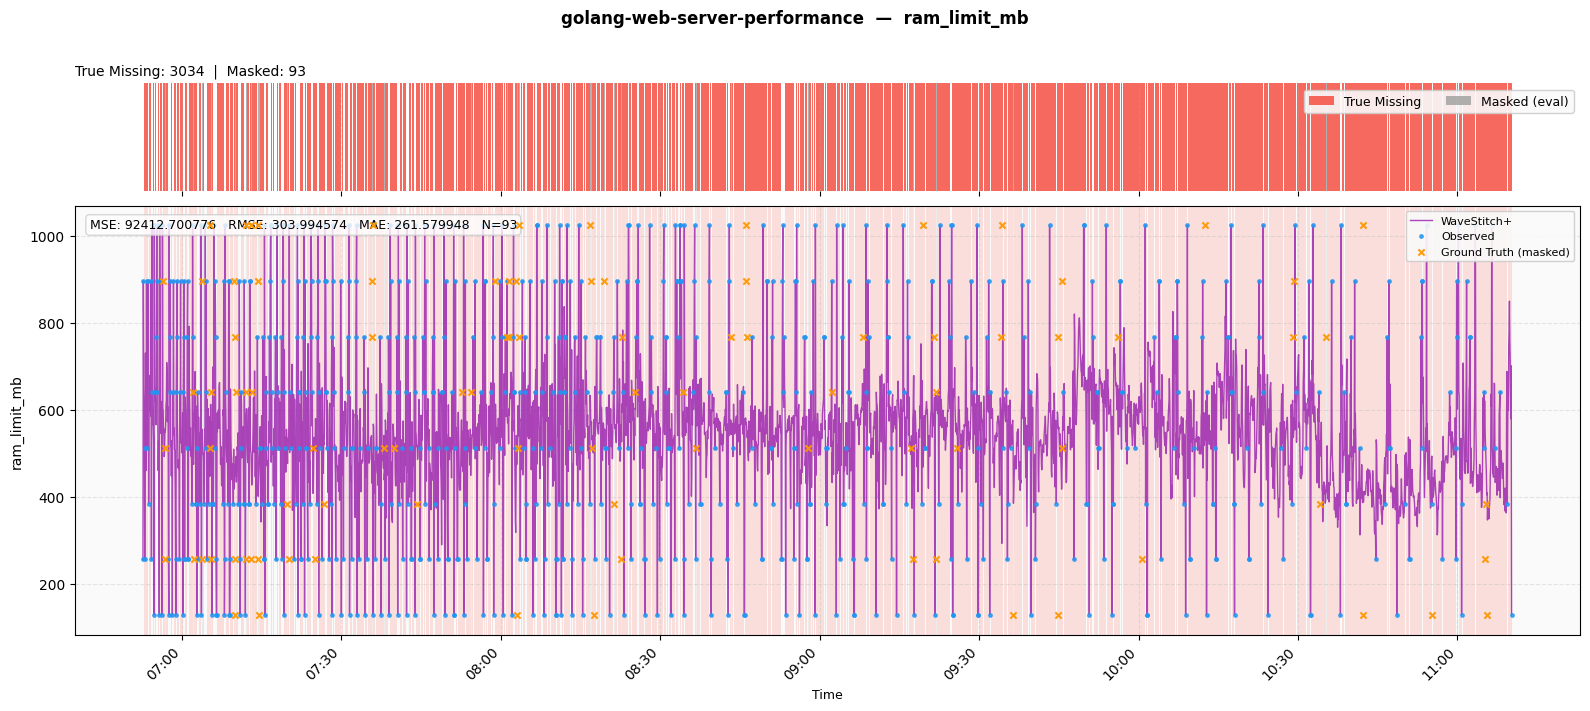

  [SAVED] EUR/curated/golang-web-server-performance/manual__2026-02-25T08:23:29.080265+00:00/comparison_plots/ram_limit_mb_wavestitchplus.png


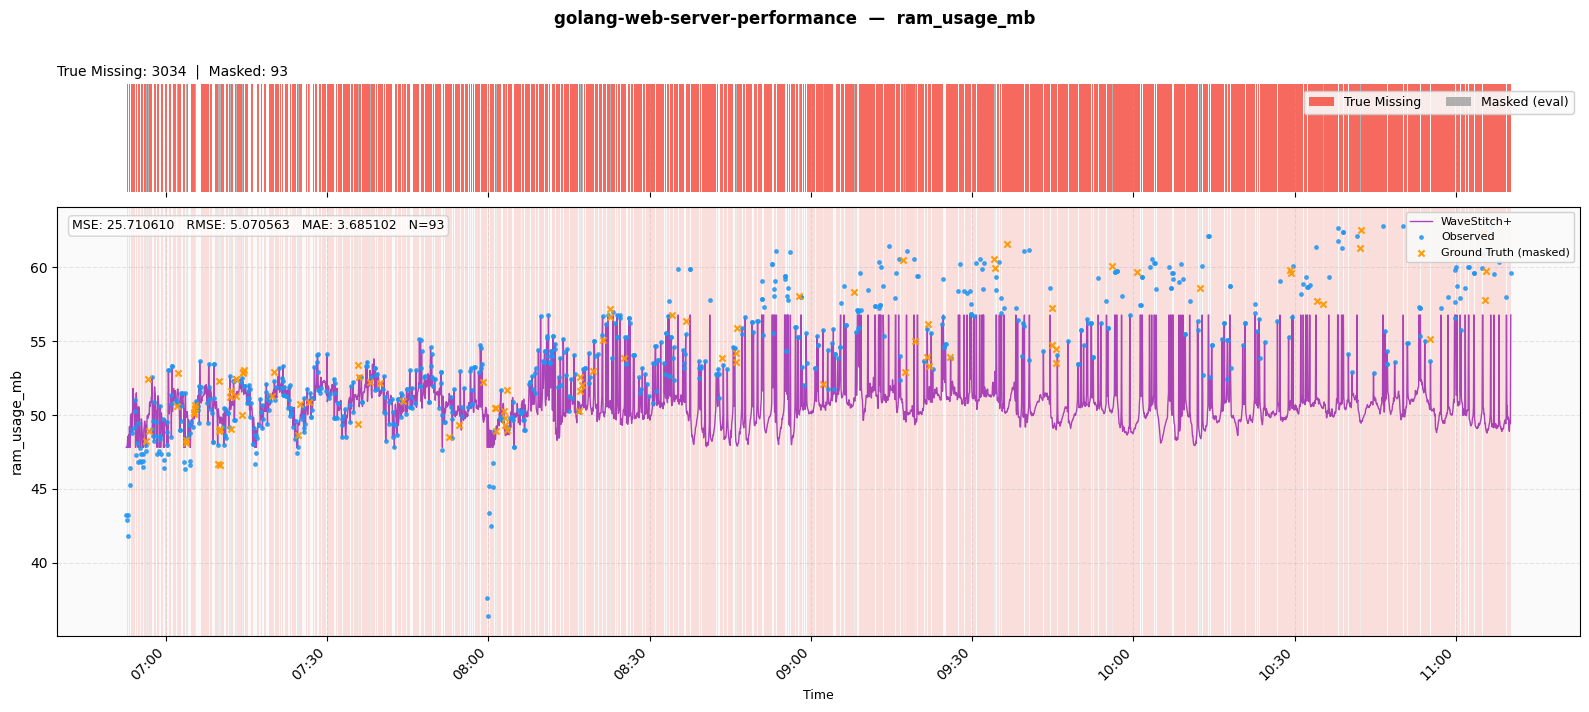

  [SAVED] EUR/curated/golang-web-server-performance/manual__2026-02-25T08:23:29.080265+00:00/comparison_plots/ram_usage_mb_wavestitchplus.png


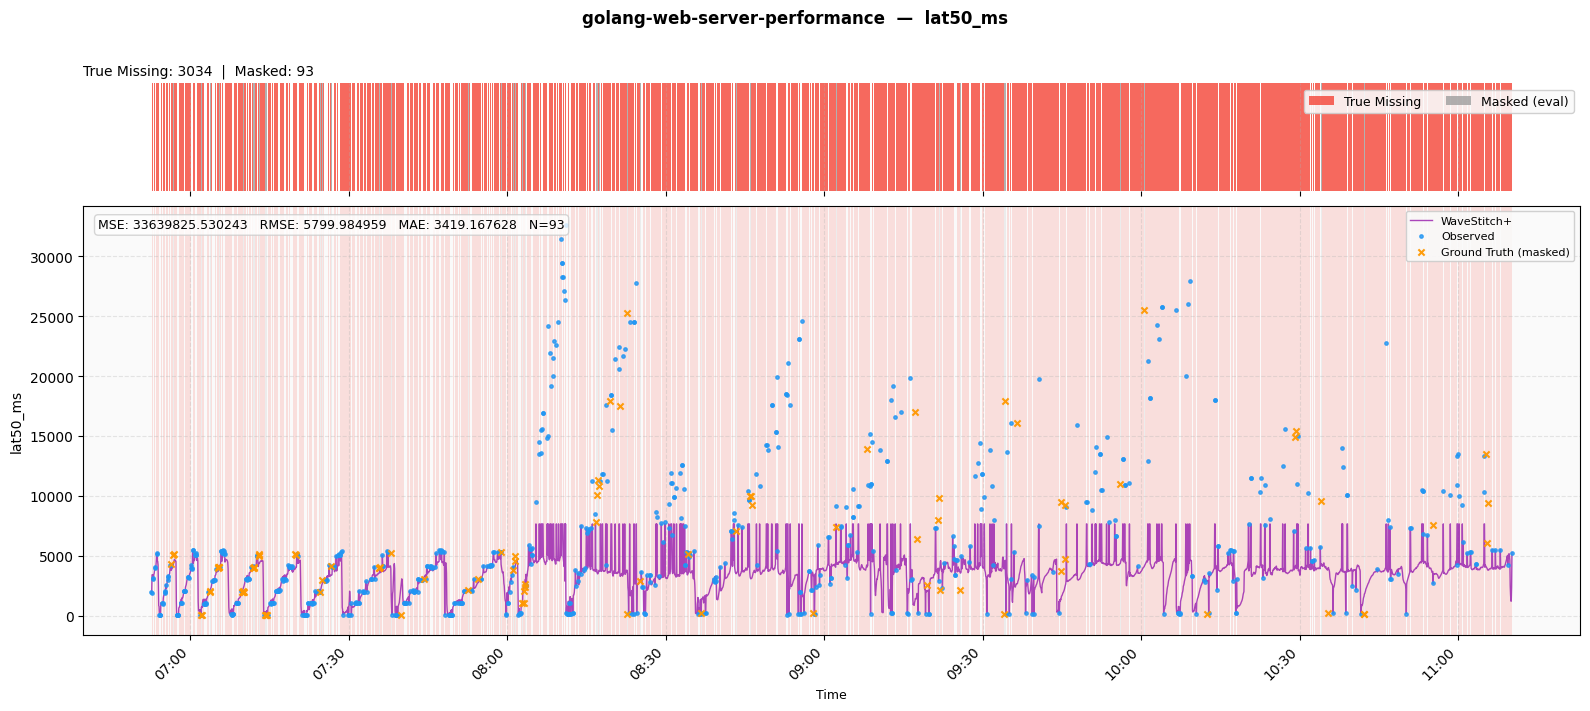

  [SAVED] EUR/curated/golang-web-server-performance/manual__2026-02-25T08:23:29.080265+00:00/comparison_plots/lat50_ms_wavestitchplus.png


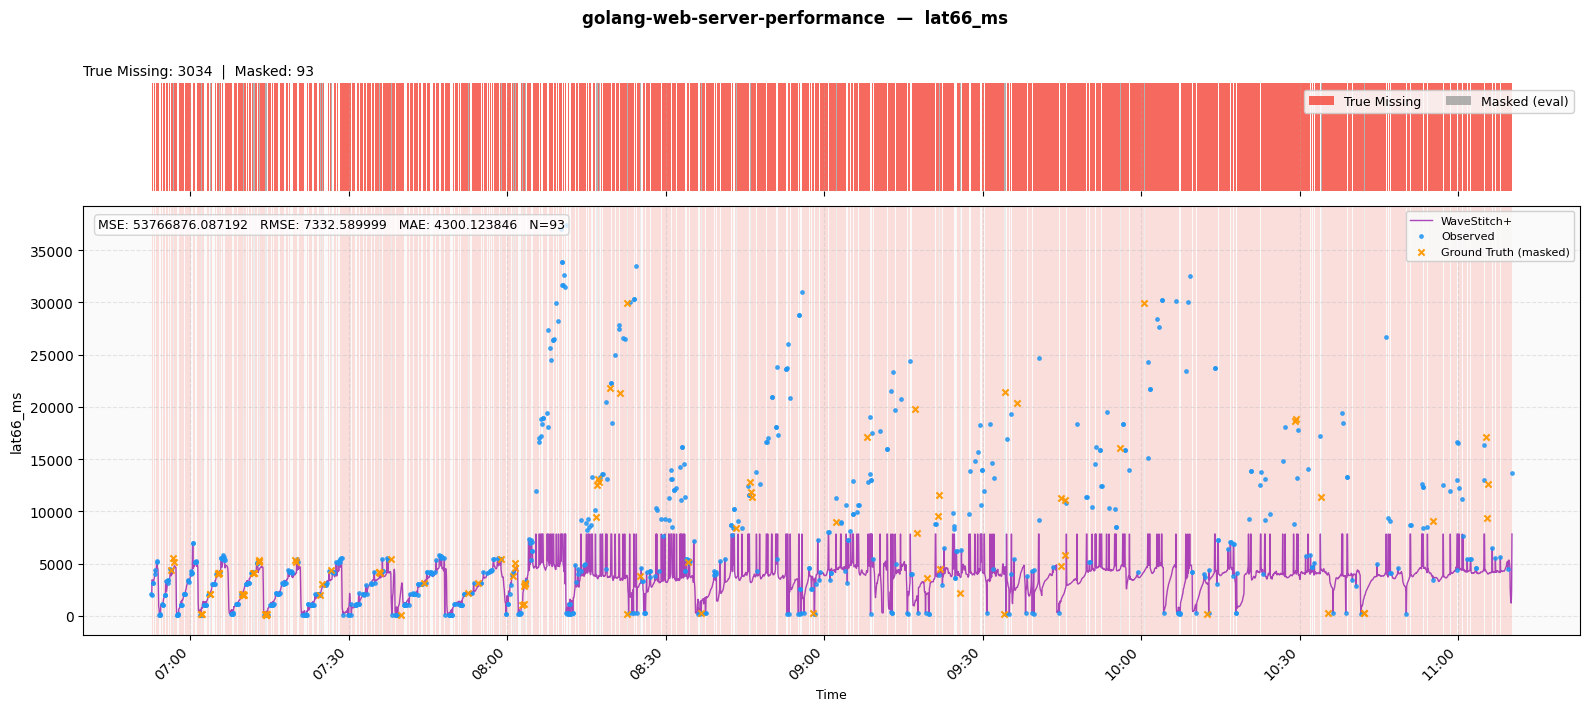

  [SAVED] EUR/curated/golang-web-server-performance/manual__2026-02-25T08:23:29.080265+00:00/comparison_plots/lat66_ms_wavestitchplus.png


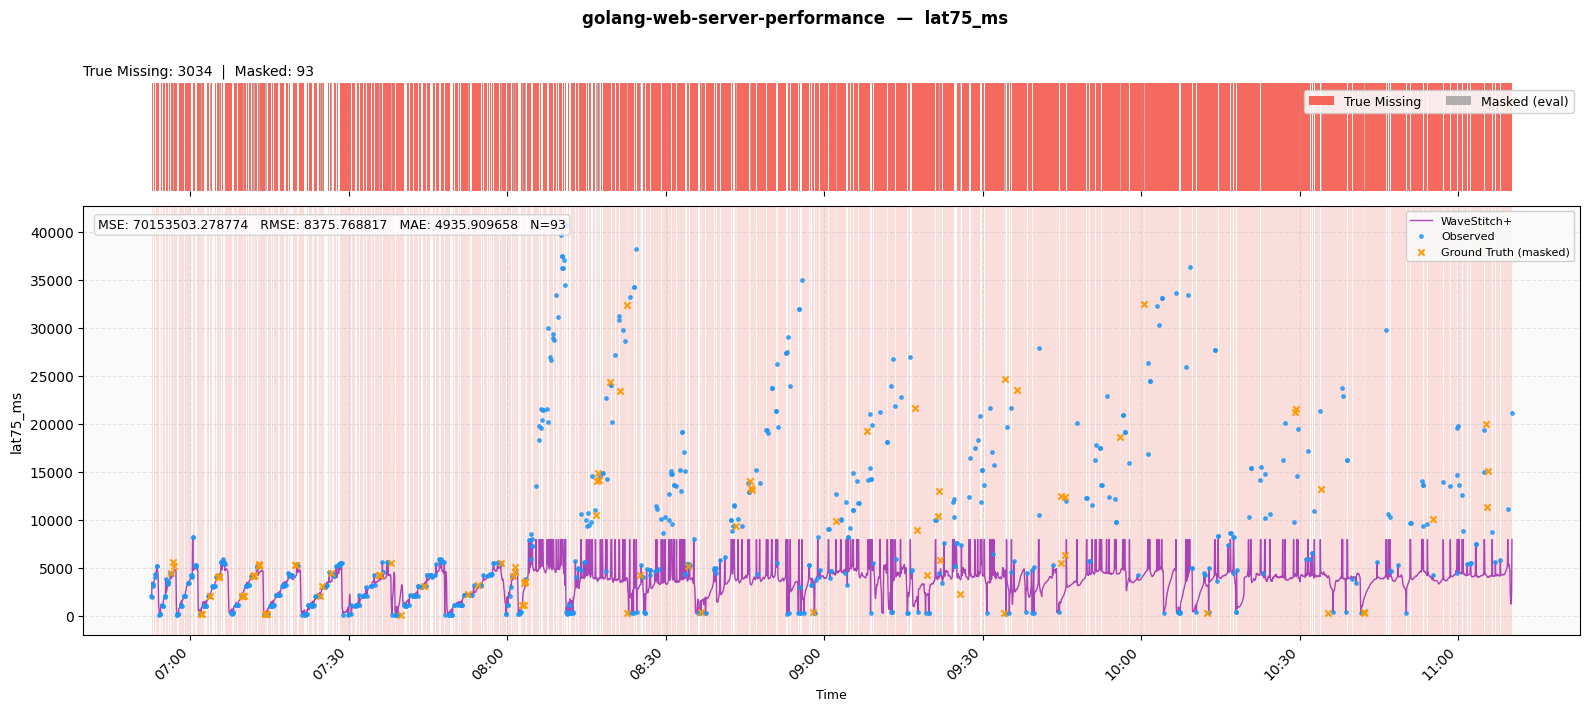

  [SAVED] EUR/curated/golang-web-server-performance/manual__2026-02-25T08:23:29.080265+00:00/comparison_plots/lat75_ms_wavestitchplus.png


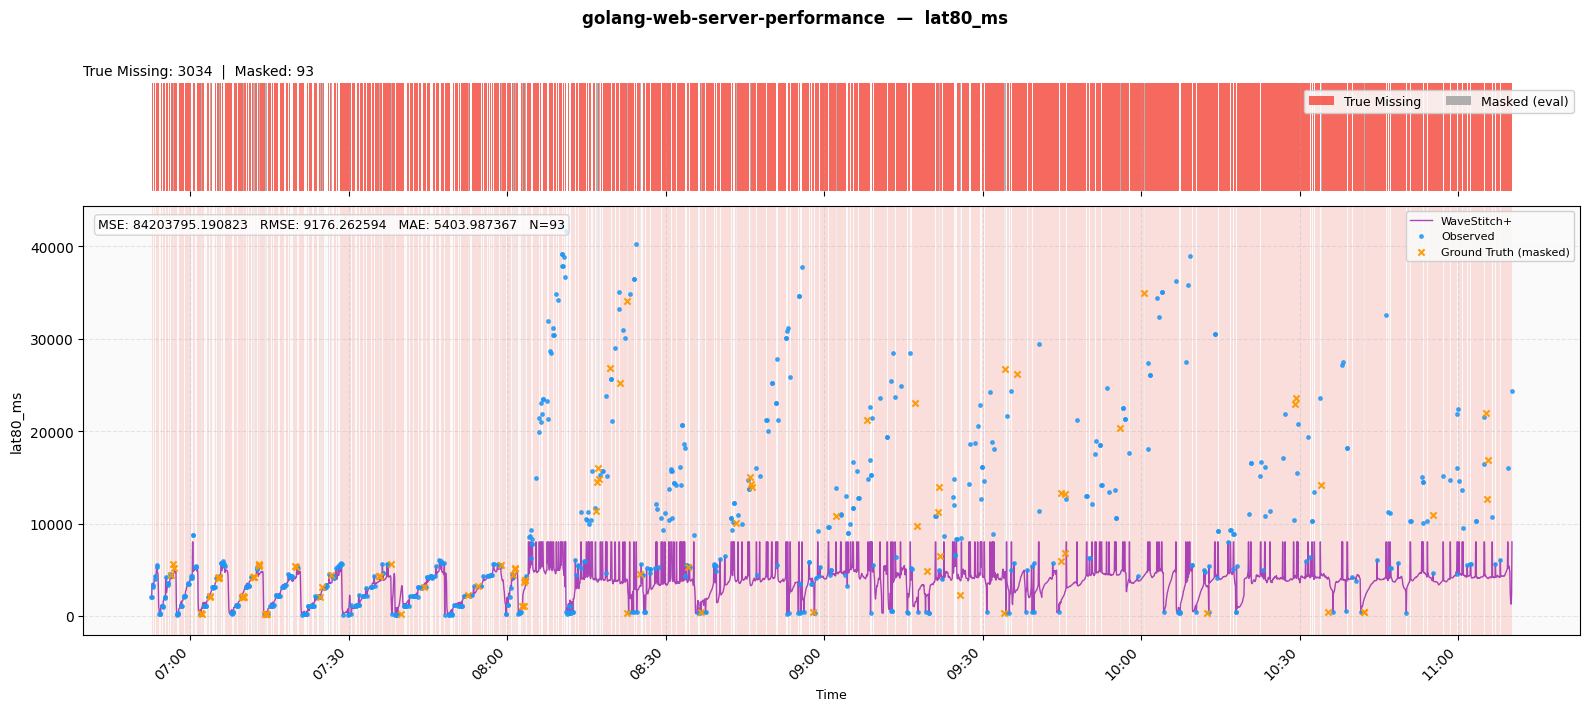

  [SAVED] EUR/curated/golang-web-server-performance/manual__2026-02-25T08:23:29.080265+00:00/comparison_plots/lat80_ms_wavestitchplus.png


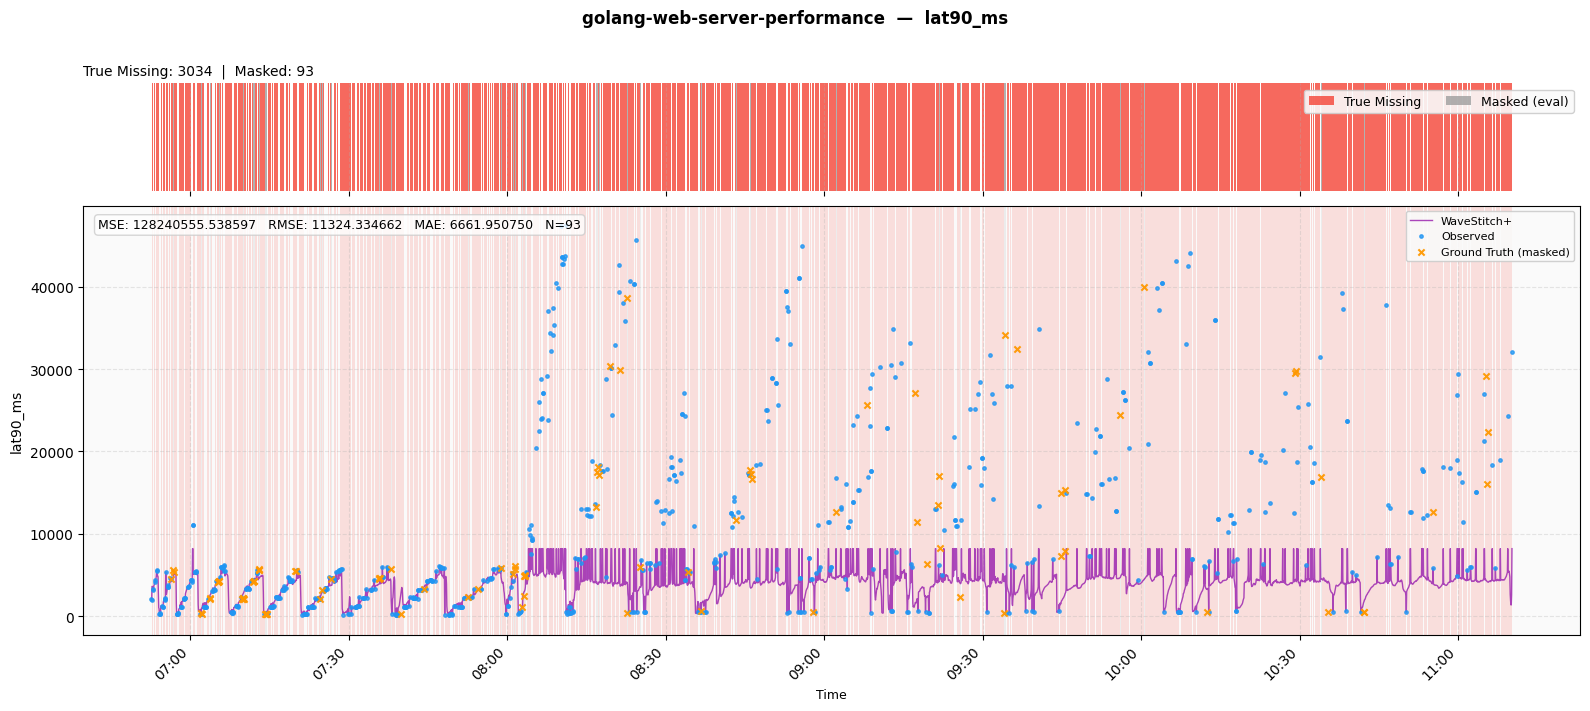

  [SAVED] EUR/curated/golang-web-server-performance/manual__2026-02-25T08:23:29.080265+00:00/comparison_plots/lat90_ms_wavestitchplus.png


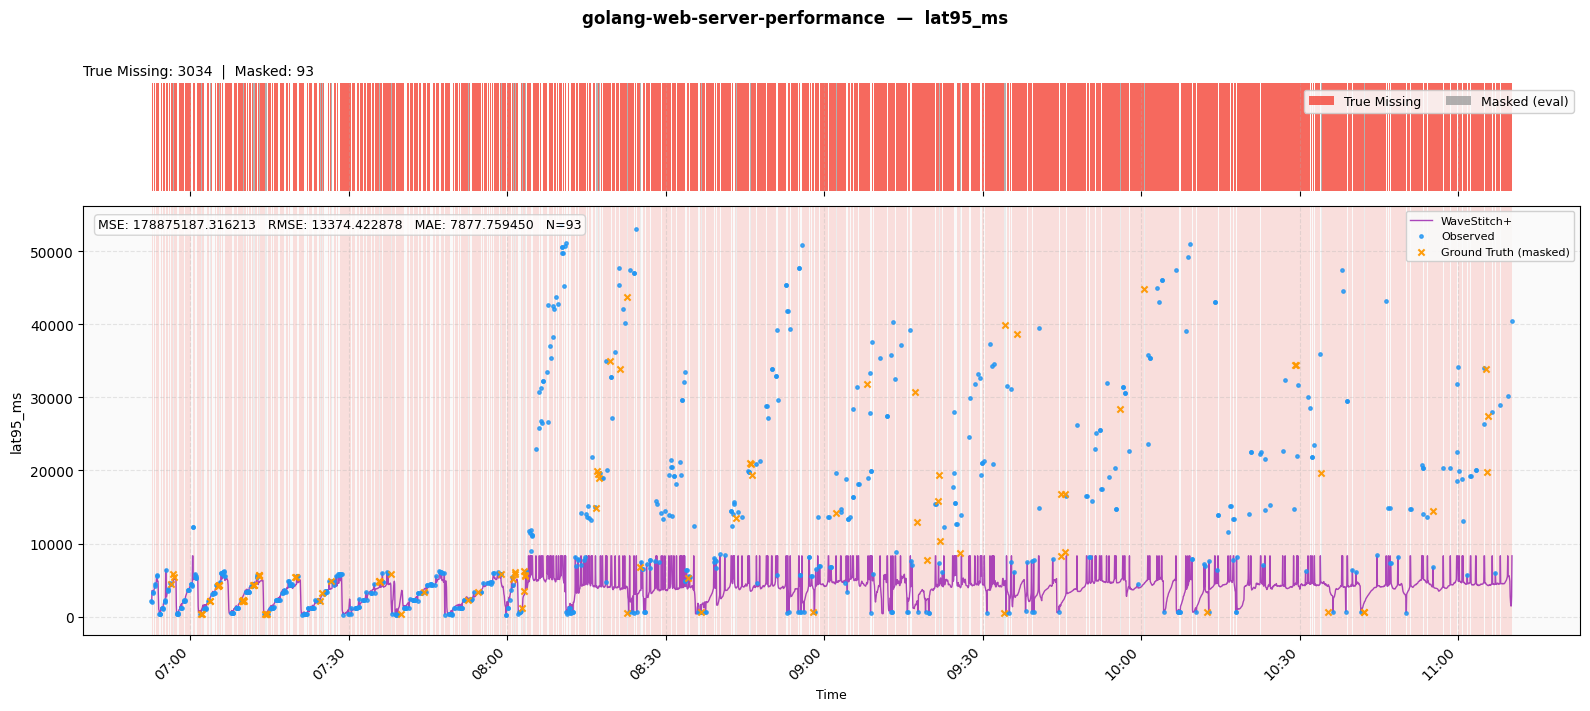

  [SAVED] EUR/curated/golang-web-server-performance/manual__2026-02-25T08:23:29.080265+00:00/comparison_plots/lat95_ms_wavestitchplus.png


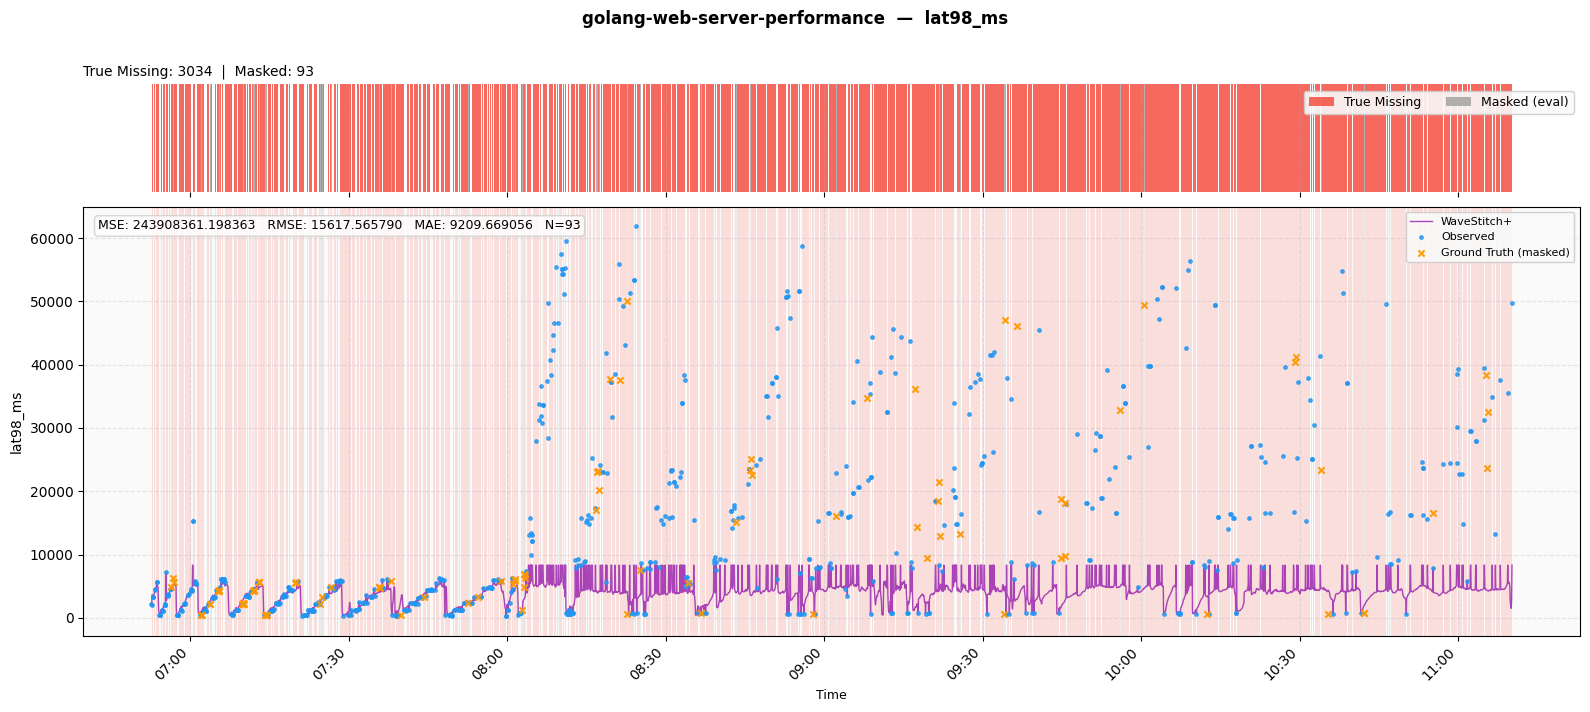

  [SAVED] EUR/curated/golang-web-server-performance/manual__2026-02-25T08:23:29.080265+00:00/comparison_plots/lat98_ms_wavestitchplus.png


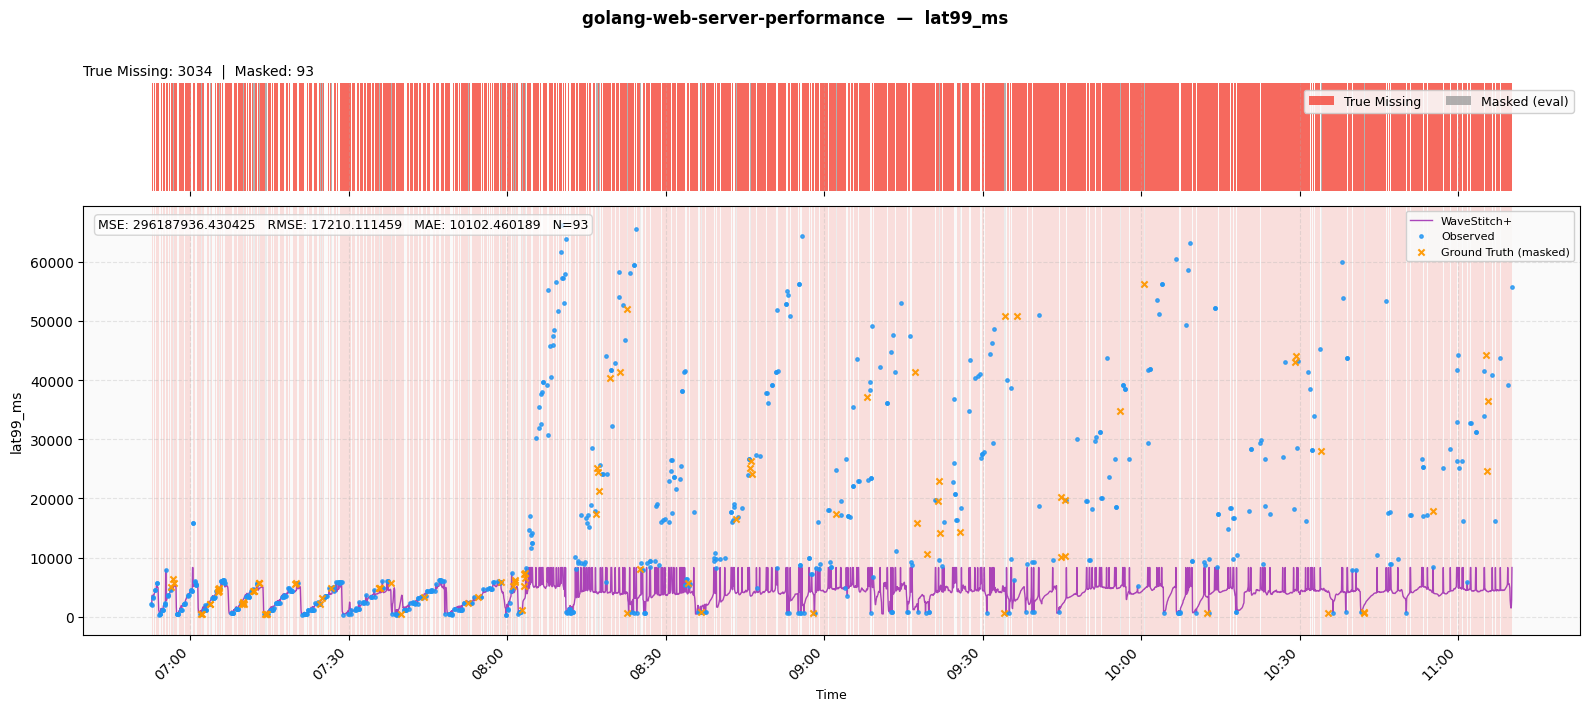

  [SAVED] EUR/curated/golang-web-server-performance/manual__2026-02-25T08:23:29.080265+00:00/comparison_plots/lat99_ms_wavestitchplus.png


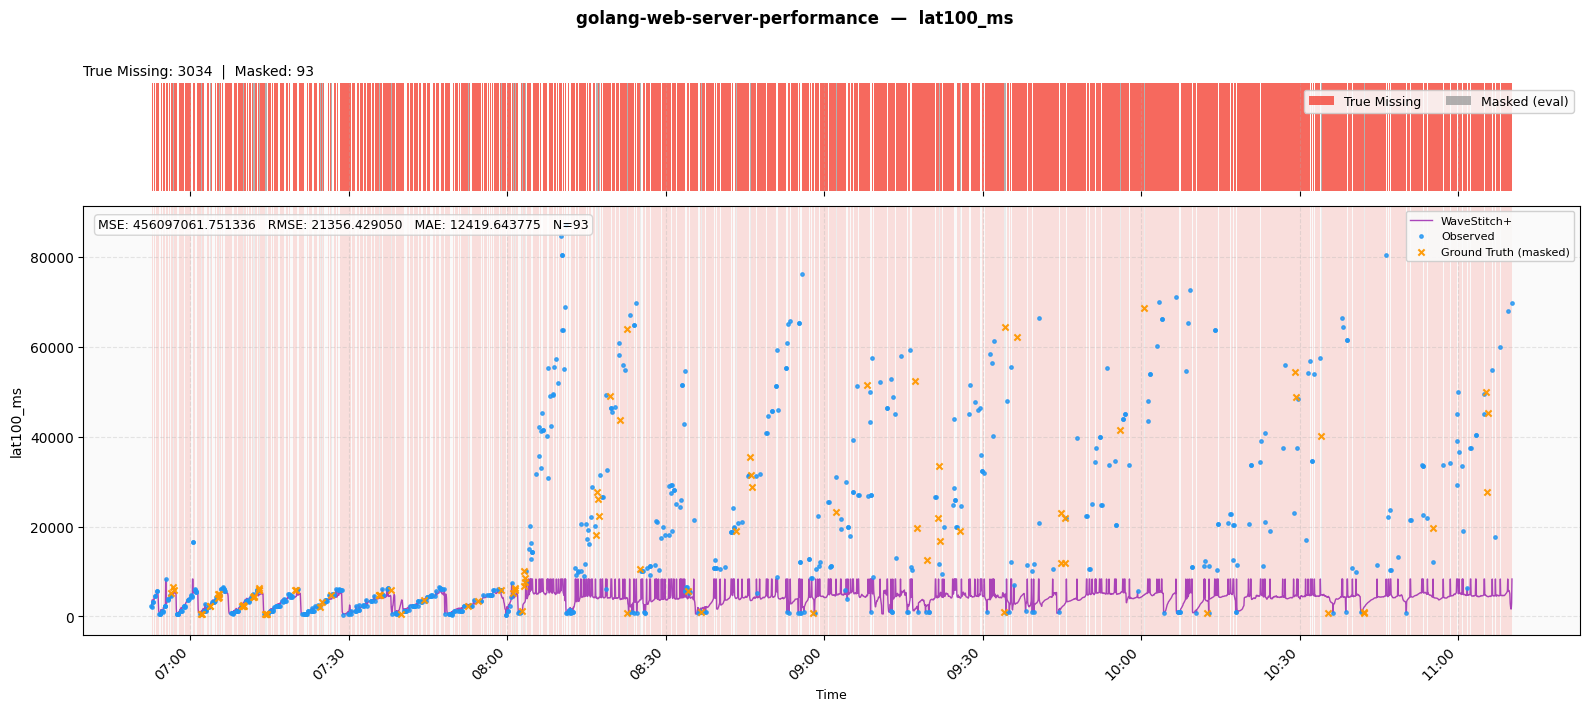

  [SAVED] EUR/curated/golang-web-server-performance/manual__2026-02-25T08:23:29.080265+00:00/comparison_plots/lat100_ms_wavestitchplus.png

[SAVED] Metrics table: EUR/curated/golang-web-server-performance/manual__2026-02-25T08:23:29.080265+00:00/comparison_plots/metrics_summary.csv
     Feature          MSE         RMSE          MAE  N_Masked
   cpu_limit 1.284507e+00     1.133361     1.021633        93
   cpu_usage 2.383465e-03     0.048821     0.041082        93
           n 5.535802e+04   235.282854   199.656515        93
           c 1.881048e+02    13.715129     9.464367        93
ram_limit_mb 9.241270e+04   303.994574   261.579948        93
ram_usage_mb 2.571061e+01     5.070563     3.685102        93
    lat50_ms 3.363983e+07  5799.984959  3419.167628        93
    lat66_ms 5.376688e+07  7332.589999  4300.123846        93
    lat75_ms 7.015350e+07  8375.768817  4935.909658        93
    lat80_ms 8.420380e+07  9176.262594  5403.987367        93
    lat90_ms 1.282406e+08 11324.334

In [17]:
#!/usr/bin/env python3
"""
visualize_imputation.py
WaveStitch+ Imputation Quality Visualization
Evaluates imputed output against ground truth on masked (held-out) regions.
"""

from __future__ import annotations

import json
import os
from pathlib import Path
from typing import Optional

import matplotlib
import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib.patches import Patch

# ─────────────────────────────────────────────
# Global style
# ─────────────────────────────────────────────
matplotlib.rcParams.update({
    "font.family":        "DejaVu Sans",
    "axes.unicode_minus": False,
    "figure.facecolor":   "white",
    "axes.facecolor":     "#FAFAFA",
    "axes.grid":          True,
    "grid.alpha":         0.3,
    "grid.linestyle":     "--",
})

COLORS = {
    "observed":      "#2196F3",   # blue  — observed input values
    "true_missing":  "#F44336",   # red   — real gaps (no ground truth)
    "masked":        "#9E9E9E",   # grey  — held-out for evaluation (GT available)
    "wavestitchplus":"#9C27B0",   # purple— WaveStitch+ prediction
    "gt":            "#FF9800",   # orange— ground truth
}

# ─────────────────────────────────────────────
# Configuration
# ─────────────────────────────────────────────
# DATASET  = "amf-performance"
# TIMELINE = "manual__2026-02-25T08:12:38.806990+00:00"

# DATASET  = "rabbitmq-performance"
# TIMELINE = "manual__2026-02-25T07:39:18.669633+00:00"

# DATASET  = "golang-web-server-performance"
# TIMELINE = "manual__2026-02-25T08:23:29.080265+00:00"

DATASET  = "python-web-server-performance"
TIMELINE = "manual__2026-02-25T09:30:58.766370+00:00"



BASE_DIR = Path("./EUR")

PREPARED_DIR      = BASE_DIR / "wavestitchplus" / DATASET / TIMELINE / "prepared"
CURATED_DIR       = BASE_DIR / "curated"        / DATASET / TIMELINE
FINAL_CLEANED_DIR = BASE_DIR / "cleaned"        / DATASET / TIMELINE
OUTPUT_DIR        = CURATED_DIR / "comparison_plots"


# ─────────────────────────────────────────────
# Data loading
# ─────────────────────────────────────────────

def load_data() -> tuple[pd.DataFrame, Optional[pd.DataFrame], pd.DataFrame, dict]:
    """Load meta, test input, ground truth, and WaveStitch+ predictions."""
    with open(PREPARED_DIR / "meta.json") as f:
        meta = json.load(f)

    raw  = pd.read_csv(PREPARED_DIR / "test_input.csv")
    gt   = pd.read_csv(PREPARED_DIR / "test_gt.csv") if (PREPARED_DIR / "test_gt.csv").exists() else None
    pred = pd.read_csv(CURATED_DIR  / "data.csv")

    print(f"\n{'='*60}")
    print(f"Dataset : {DATASET}")
    print(f"Target  : {meta.get('target_cols', [])}")
    print(f"{'='*60}")
    print(f"test_input  : {raw.shape}")
    print(f"WaveStitch+ : {pred.shape}")
    if gt is not None:
        print(f"ground truth: {gt.shape}")
    print()

    return raw, gt, pred, meta


# ─────────────────────────────────────────────
# Time parsing
# ─────────────────────────────────────────────

def parse_time(df: pd.DataFrame, time_col: str) -> pd.DatetimeIndex:
    if time_col not in df.columns:
        return pd.to_datetime(range(len(df)), unit="s")
    s = df[time_col]
    if pd.api.types.is_numeric_dtype(s):
        unit = "ms" if s.max() > 1e12 else "s"
        return pd.to_datetime(s, unit=unit)
    return pd.to_datetime(s)


def setup_time_axis(ax: plt.Axes, time_index: pd.DatetimeIndex) -> None:
    duration = time_index.max() - time_index.min()
    if duration.days > 30:
        fmt = "%Y-%m-%d"
    elif duration.days > 1:
        fmt = "%m-%d %H:%M"
    elif duration.total_seconds() > 3600:
        fmt = "%H:%M"
    else:
        fmt = "%H:%M:%S"
    ax.xaxis.set_major_formatter(mdates.DateFormatter(fmt))
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=45, ha="right")


# ─────────────────────────────────────────────
# Mask classification
# ─────────────────────────────────────────────

def classify_mask(
    raw: pd.DataFrame,
    gt: Optional[pd.DataFrame],
    feature: str,
) -> np.ndarray:
    """
    Classify each timestep as one of:
      'observed'     — value present in test input
      'true_missing' — real gap (is_gap=True) or GT also missing
      'masked'       — held-out for evaluation (GT available, input NaN)
    """
    n          = len(raw)
    mask_type  = np.full(n, "observed", dtype=object)
    is_gap     = raw["is_gap"].values.astype(bool) if "is_gap" in raw.columns else np.zeros(n, bool)
    input_nan  = raw[feature].isna().values if feature in raw.columns else np.ones(n, bool)
    gt_present = (~gt[feature].isna().values if gt is not None and feature in gt.columns
                  else np.zeros(n, bool))

    for i in range(n):
        if not input_nan[i]:
            mask_type[i] = "observed"
        elif is_gap[i] or not gt_present[i]:
            mask_type[i] = "true_missing"
        else:
            mask_type[i] = "masked"

    return mask_type


# ─────────────────────────────────────────────
# Metrics
# ─────────────────────────────────────────────

def compute_metrics(
    raw: pd.DataFrame,
    gt: Optional[pd.DataFrame],
    pred: pd.DataFrame,
    feature: str,
) -> dict:
    """Compute MSE and MAE on masked (held-out) positions only."""
    if gt is None or feature not in gt.columns or feature not in pred.columns:
        return {"mse": None, "mae": None, "rmse": None, "n": 0}

    mask_type = classify_mask(raw, gt, feature)
    idx       = mask_type == "masked"
    n         = idx.sum()

    if n == 0:
        return {"mse": None, "mae": None, "rmse": None, "n": 0}

    gt_vals   = gt[feature].values[idx]
    pred_vals = pred[feature].values[idx]
    valid     = ~(np.isnan(gt_vals) | np.isnan(pred_vals))

    if valid.sum() == 0:
        return {"mse": None, "mae": None, "rmse": None, "n": 0}

    err  = gt_vals[valid] - pred_vals[valid]
    mse  = float(np.mean(err ** 2))
    mae  = float(np.mean(np.abs(err)))
    rmse = float(np.sqrt(mse))

    return {"mse": mse, "mae": mae, "rmse": rmse, "n": int(n)}


# ─────────────────────────────────────────────
# Summary printing
# ─────────────────────────────────────────────

def print_mask_summary(
    raw: pd.DataFrame,
    gt: Optional[pd.DataFrame],
    target_cols: list[str],
) -> None:
    print(f"\n{'='*72}")
    print(f"{'Feature':<22} {'Observed':>10} {'True Missing':>14} {'Masked':>10}")
    print(f"{'='*72}")
    for feat in target_cols:
        if feat not in raw.columns:
            continue
        mt = classify_mask(raw, gt, feat)
        print(f"{feat:<22} {(mt=='observed').sum():>10} "
              f"{(mt=='true_missing').sum():>14} {(mt=='masked').sum():>10}")
    print(f"{'='*72}\n")


def print_metrics_summary(
    raw: pd.DataFrame,
    gt: Optional[pd.DataFrame],
    pred: pd.DataFrame,
    target_cols: list[str],
) -> list[dict]:
    print(f"\n{'='*72}")
    print("Imputation Metrics on Masked Regions (WaveStitch+)")
    print(f"{'='*72}")
    print(f"{'Feature':<22} {'MSE':>12} {'RMSE':>12} {'MAE':>12} {'N':>8}")
    print(f"{'-'*72}")

    rows = []
    for feat in target_cols:
        m = compute_metrics(raw, gt, pred, feat)
        mse_s  = f"{m['mse']:.6f}"  if m["mse"]  is not None else "N/A"
        rmse_s = f"{m['rmse']:.6f}" if m["rmse"] is not None else "N/A"
        mae_s  = f"{m['mae']:.6f}"  if m["mae"]  is not None else "N/A"
        print(f"{feat:<22} {mse_s:>12} {rmse_s:>12} {mae_s:>12} {m['n']:>8}")
        rows.append({"Feature": feat, "MSE": m["mse"], "RMSE": m["rmse"],
                     "MAE": m["mae"], "N_Masked": m["n"]})

    print(f"{'='*72}\n")
    return rows


# ─────────────────────────────────────────────
# Background highlight helper
# ─────────────────────────────────────────────

def _add_background_spans(
    ax: plt.Axes,
    mask_type: np.ndarray,
    time_index: pd.DatetimeIndex,
    alpha: float = 0.2,
) -> None:
    """Shade true_missing (red) and masked (grey) regions."""
    for i in range(len(mask_type) - 1):
        t_start = time_index[i]
        t_end   = time_index[i + 1]
        if mask_type[i] == "true_missing":
            ax.axvspan(t_start, t_end, alpha=alpha, color=COLORS["true_missing"], linewidth=0)
        elif mask_type[i] == "masked":
            ax.axvspan(t_start, t_end, alpha=alpha, color=COLORS["masked"],       linewidth=0)


# ─────────────────────────────────────────────
# Per-feature plot
# ─────────────────────────────────────────────

def plot_feature(
    feature: str,
    raw: pd.DataFrame,
    gt: Optional[pd.DataFrame],
    pred: pd.DataFrame,
    time_index: pd.DatetimeIndex,
    metrics: dict,
) -> None:
    mask_type      = classify_mask(raw, gt, feature)
    observed_mask  = mask_type == "observed"
    masked_mask    = mask_type == "masked"
    true_miss_mask = mask_type == "true_missing"

    raw_values = raw[feature].values if feature in raw.columns else np.full(len(raw), np.nan)

    fig, (ax_bar, ax_main) = plt.subplots(
        2, 1, figsize=(16, 7), sharex=True,
        gridspec_kw={"height_ratios": [0.25, 1]},
    )
    fig.patch.set_facecolor("white")

    # # ── Mask bar ─────────────────────────────
    # for i in range(len(mask_type) - 1):
    #     if mask_type[i] == "true_missing":
    #         color = COLORS["true_missing"]
    #     elif mask_type[i] == "masked":
    #         color = COLORS["masked"]
    #     else:
    #         color = "#E8F5E9"   # very light green for observed
    #     ax_bar.axvspan(time_index[i], time_index[i + 1],
    #                    alpha=0.9, color=color, linewidth=0)

    # ax_bar.set_ylim(0, 1)
    # ax_bar.set_yticks([])
    # ax_bar.set_facecolor("white")
    # ax_bar.spines[["top", "right", "left"]].set_visible(False)
    # ax_bar.set_title(
    #     f"Data Availability  |  Observed: {observed_mask.sum()}  "
    #     f"True Missing: {true_miss_mask.sum()}  "
    #     f"Held-out (Masked): {masked_mask.sum()}",
    #     fontsize=9, loc="left", pad=4,
    # )
    # ax_bar.legend(
    #     handles=[
    #         Patch(facecolor=COLORS["true_missing"], alpha=0.9, label="True Missing"),
    #         Patch(facecolor=COLORS["masked"],       alpha=0.9, label="Masked (eval)"),
    #         Patch(facecolor="#E8F5E9",              alpha=0.9, label="Observed"),
    #     ],
    #     loc="upper right", ncol=3, fontsize=8, framealpha=0.9,
    # )
    # ── Mask bar ─────────────────────────────
    for i in range(len(mask_type) - 1):
        if mask_type[i] == "true_missing":
            color = COLORS["true_missing"]
        elif mask_type[i] == "masked":
            color = COLORS["masked"]
        else:
            color = "white"
        ax_bar.axvspan(
            time_index[i], time_index[i + 1],
            alpha=0.8, color=color, linewidth=0,
        )

    ax_bar.set_ylim(0, 1)
    ax_bar.set_yticks([])
    ax_bar.set_facecolor("white")
    ax_bar.spines[["top", "right", "left", "bottom"]].set_visible(False)
    ax_bar.legend(
        handles=[
            Patch(facecolor=COLORS["true_missing"], alpha=0.8, label="True Missing"),
            Patch(facecolor=COLORS["masked"],       alpha=0.8, label="Masked (eval)"),
        ],
        loc="upper right", ncol=2, fontsize=9, framealpha=0.9,
    )
    ax_bar.set_title(
        f"True Missing: {true_miss_mask.sum()}  |  Masked: {masked_mask.sum()}",
        fontsize=10, loc="left",
    )
    # ── Main panel ───────────────────────────
    _add_background_spans(ax_main, mask_type, time_index, alpha=0.15)

    # WaveStitch+ prediction (full line)
    if feature in pred.columns:
        ax_main.plot(
            time_index, pred[feature].values,
            color=COLORS["wavestitchplus"], linewidth=1.0,
            alpha=0.85, label="WaveStitch+", zorder=2,
        )

    # Observed input points
    ax_main.scatter(
        time_index[observed_mask], raw_values[observed_mask],
        s=6, color=COLORS["observed"], alpha=0.8,
        label="Observed", zorder=3,
    )

    # Ground truth on masked positions
    if gt is not None and feature in gt.columns:
        gt_vals = gt[feature].values
        ax_main.scatter(
            time_index[masked_mask], gt_vals[masked_mask],
            s=20, color=COLORS["gt"], alpha=0.95,
            marker="x", linewidths=1.5,
            label="Ground Truth (masked)", zorder=5,
        )

    # Metrics annotation
    mse_s  = f"{metrics['mse']:.6f}"  if metrics["mse"]  is not None else "N/A"
    rmse_s = f"{metrics['rmse']:.6f}" if metrics["rmse"] is not None else "N/A"
    mae_s  = f"{metrics['mae']:.6f}"  if metrics["mae"]  is not None else "N/A"

    ax_main.annotate(
        f"MSE: {mse_s}   RMSE: {rmse_s}   MAE: {mae_s}   N={metrics['n']}",
        xy=(0.01, 0.97), xycoords="axes fraction",
        fontsize=9, va="top",
        bbox=dict(boxstyle="round,pad=0.3", facecolor="white", alpha=0.8, edgecolor="#CCCCCC"),
    )

    ax_main.set_ylabel(feature, fontsize=10)
    ax_main.legend(loc="upper right", fontsize=8, framealpha=0.9)
    setup_time_axis(ax_main, time_index)
    ax_main.set_xlabel("Time", fontsize=9)

    fig.suptitle(
        f"{DATASET}  —  {feature}",
        fontsize=12, fontweight="bold", y=1.01,
    )
    plt.tight_layout()
    plt.show()
    save_path = OUTPUT_DIR / f"{feature}_wavestitchplus.png"
    plt.savefig(save_path, dpi=150, bbox_inches="tight")
    plt.close()
    print(f"  [SAVED] {save_path}")


# ─────────────────────────────────────────────
# Main
# ─────────────────────────────────────────────

def main() -> None:
    OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

    raw, gt, pred, meta = load_data()

    time_col    = meta.get("time_col",    "time")
    target_cols = meta.get("target_cols", [])

    time_index = parse_time(raw, time_col)
    print(f"Time range: {time_index.min()}  →  {time_index.max()}\n")

    # ── Summary tables ───────────────────────
    print_mask_summary(raw, gt, target_cols)
    metric_rows = print_metrics_summary(raw, gt, pred, target_cols)

    # ── Per-feature plots ────────────────────
    print("[PLOTTING] Generating per-feature comparison plots...")
    for feat in target_cols:
        if feat not in raw.columns:
            print(f"  [SKIP] '{feat}' not in test_input.csv")
            continue
        m = compute_metrics(raw, gt, pred, feat)
        plot_feature(feat, raw, gt, pred, time_index, m)

    # ── Save metrics CSV ─────────────────────
    if metric_rows:
        results_df = pd.DataFrame(metric_rows)
        csv_path   = OUTPUT_DIR / "metrics_summary.csv"
        results_df.to_csv(csv_path, index=False)
        print(f"\n[SAVED] Metrics table: {csv_path}")
        print(results_df.to_string(index=False))

    print(f"\n[DONE] All plots saved to: {OUTPUT_DIR}")


if __name__ == "__main__":
    main()